### BB84 Quantum Key Distribution Protocol 
#### Quantum Information and Computing (QIC) Mini-Project

This project implements the BB84 Quantum Key Distribution protocol, which enables two parties (Alice and Bob) to securely generate a shared secret key using quantum mechanics.

Alice encodes classical bits into quantum states using randomly chosen rectilinear(Z) or diagonal(X) bases. Bob measures the received qubits using his own random bases. After transmission, Alice and Bob publicly compare their basis choices over a classical channel and discard any bits where their bases mismatched. (key sifting).

To ensure security, part of the key is compared to compute the Quantum Bit Error Rate (QBER). If QBER is high, it indicates noise or the presence of an eavesdropper (Eve)

The implementation uses Qiskit for circuit simulation via AerSimulator and is compatible with IBM Quantum hardware through Qiskit Runtime.


In [1]:
import random
from dataclasses import dataclass
from typing import List, Optional
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.providers import Backend
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform", 
#     token="", 
#     overwrite=True
# )

In [3]:
# =============================================================================
# SECTION 1: DATA CONTAINERS AND HELPERS
# =============================================================================

@dataclass
class BB84Result:
    """Container for storing BB84 results"""
    raw_bits_alice: list[int]
    raw_bits_bob: list[int]
    bases_alice: list[str]
    bases_bob: list[str]
    sifted_key: list[int]
    check_qber: float
    key_length_raw: int
    key_length_sifted: int
    eve_present: bool
    backend_name: str

def sample_bits(n: int, seed: Optional[int]= None) -> list[int]:
    """Generate a sequence of random classical bits consisting of zeros and ones."""
    rand = random.Random(seed)
    return [rand.randint(0, 1) for _ in range(n)]

def sample_bases(n: int, seed: Optional[int] = None) -> list[str]:
    """
    Generate a sequence of random measurement bases of Z and X.
    'Z' is the rectilinear (computational) basis: {|0⟩, |1⟩}.
    'X' is the diagonal (Hadamard) basis:         {|+⟩, |−⟩}.
    """
    rng = random.Random(seed)
    return [rng.choice(['Z', 'X']) for _ in range(n)]

In [4]:
# =============================================================================
# SECTION 2: QUANTUM CIRCUIT CONSTRUCTION
# =============================================================================

def build_bb84_circuit(
    alice_bits: list[int],
    alice_bases: list[str],
    bob_bases: list[str],
    eve_bases: Optional[list[str]] = None,
) -> QuantumCircuit:
    """
    Construct the quantum circuit to simulate Alice encoding bits, Eve intercepting them, and Bob measuring the results.
    Steps:
    1. Alice encodes (bits_alice[i], bases_alice[i]):
        (0, Z) → |0⟩      : no gate (default state)
        (1, Z) → |1⟩      : X gate
        (0, X) → |+⟩      : H gate
        (1, X) → |−⟩      : X gate → H gate

    2. Eve measures and re-encodes in her random basis.
    Measuring in the wrong basis with probability 1/2 collapses the state,
    and re-encoding introduces a 25% per-bit error to Bob.

    3. Bob measures:
        bases_bob[i] == 'Z' : measure in computational basis
        bases_bob[i] == 'X' : apply H before measuring (rotate to Z basis)
    """
    n = len(alice_bits)
    qr = QuantumRegister(n, name='q')      # one qubit per transmitted bit
    cr_bob = ClassicalRegister(n, name='c_bob') # Bob's measurements
    # Hardware optimisation: Separate classical register for Eve to allow mid-circuit measurement without destroying Bob's final results.
    if eve_bases is not None:
        cr_eve = ClassicalRegister(n, name='c_eve')
        qc = QuantumCircuit(qr, cr_eve, cr_bob)
    else:
        qc = QuantumCircuit(qr, cr_bob)

    # 1. Alice prepares her states
    for i in range(n):
        if alice_bases[i] == 'Z':
            if alice_bits[i] == 1:
                qc.x(qr[i])
        else:  
            if alice_bits[i] == 1:
                qc.x(qr[i])
            qc.h(qr[i])

    qc.barrier(label='Alice_to_Channel')

    # 2. Eve intercepts the transmission
    if eve_bases is not None:
        for i in range(n):
            if eve_bases[i] == 'X':
                qc.h(qr[i])
            # Eve measures
            qc.measure(qr[i], cr_eve[i])
            
            # Eve re-prepares the state based on her measurement basis
            if eve_bases[i] == 'X':
                qc.h(qr[i])

        qc.barrier(label='Eve_to_Channel')
        
    # 3. Bob measurements
    for i in range(n):
        if bob_bases[i] == 'X':
            qc.h(qr[i])              

        qc.measure(qr[i], cr_bob[i])    # measure in computational (Z) basis

    return qc

In [5]:
# =============================================================================
# SECTION 3 — KEY SIFTING and QBER 
# =============================================================================

def sift_key(
    alice_bits: list[int],
    alice_bases: list[str],
    bob_bits: list[int],
    bob_bases: list[str],
) -> tuple[list[int], list[int], list[int]]:
    """
    Perform basis sifting: keep only the bit positions where Alice and Bob
    used the same basis (publicly announced over a classical channel).
    """
    matching_indices = []
    alice_sifted_key = []  
    bob_sifted_key = []   
    for i in range(len(alice_bases)):
        if alice_bases[i] == bob_bases[i]:
            matching_indices.append(i)
            alice_sifted_key.append(alice_bits[i])
            bob_sifted_key.append(bob_bits[i])
    return alice_sifted_key, bob_sifted_key, matching_indices

def compute_qber(
    alice_sifted_key: list[int],
    bob_sifted_key: list[int],
    check_fraction: float = 0.5,
    seed: Optional[int] = None,
) -> tuple[float, list[int], list[int]]:
    """
    Compute  the Quantum Bit Error Rate (QBER) by sacrificing a random subset of the sifted key as publicly-compared 'check bits'.
    The remaining bits form the final usable shared secret key.
    """
    rng = random.Random(seed)
    n_sifted = len(alice_sifted_key)

    # ensure both keys match in length
    if n_sifted != len(bob_sifted_key):
        raise ValueError("[Error] : Alice and Bob's sifted keys must be the exact same length!")
    
    if n_sifted == 0:
        return 0.0, [], []

    # Select random check bit positions
    n_check = max(1, int(n_sifted * check_fraction))
    check_indices = rng.sample(range(n_sifted), n_check)
    check_set = set(check_indices)

    # Count disagreements among check bits
    errors_indices = []
    for idx in check_indices:
        if alice_sifted_key[idx] != bob_sifted_key[idx]:
            errors_indices.append(idx)
    errors = len(errors_indices)
    qber = errors / n_check if n_check > 0 else 0.0

    # Remove check bits from the final usable secret key
    final_key = []
    for i in range(n_sifted):
        if i not in check_set:
          final_key.append(alice_sifted_key[i])  

    return qber, final_key, check_indices

In [23]:
# =============================================================================
# SECTION 4 — BACKEND EXECUTION HELPERS
# =============================================================================

def get_clean_backend() -> AerSimulator:
    """
    Return a noiseless AerSimulator.
    """
    return AerSimulator()

def get_noisy_backend(
    depol_prob: float = 0.01,
    readout_error_prob: float = 0.02,
) -> AerSimulator:
    """
    Build an AerSimulator with a simple depolarizing + readout noise model
    """
    noise_model = NoiseModel()
    # Depolarizing error on single-qubit gates (X and H are our only gates we use in this implmentation)
    depol_error = depolarizing_error(depol_prob, 1)
    noise_model.add_all_qubit_quantum_error(depol_error, ['x', 'h', 'reset'])

    # Bit-flip during measurement error: [[P(0|0), P(1|0)], [P(0|1), P(1|1)]]
    p0given0 = 1.0 - readout_error_prob   # correct 0 reading
    p1given1 = 1.0 - readout_error_prob   # correct 1 reading
    ro_error = ReadoutError([
        [p0given0, readout_error_prob],
        [readout_error_prob, p1given1],
    ])
    noise_model.add_all_qubit_readout_error(ro_error)
    return AerSimulator(noise_model=noise_model)
        
def execute_circuit(
    qc: QuantumCircuit,
    backend: AerSimulator,
    shots: int = 1,
) -> list[int]:
    """
    Run a circuit on a local Aer backend.
    Uses native execution with memory=True to guarantee noise model injection
    while perfectly preserving the chronological timeline.
    """
    tqc = transpile(qc,  basis_gates=['x', 'h', 'measure', 'reset'], optimization_level=0)
    # Native execution with memory=True to get the chronological list
    job = backend.run(tqc, shots=shots, memory=True)
    result = job.result()
    bob_raw_key = []
    eve_raw_key = []
    bitstrings = result.get_memory()
    for shot_string in bitstrings:
        registers = shot_string.split()
        # In Qiskit format last-added register appears first
        # c_bob was added last so it is registers[0]
        bob_string = registers[0]
        shot_bits_bob = [int(bit) for bit in reversed(bob_string)]
        bob_raw_key.extend(shot_bits_bob)
        
        # c_eve was added first so it is registers[-1]
        # (If Eve is not present, there's only 1 register, so it safely skips this)
        if len(registers) > 1:
            eve_string = registers[-1] 
            shot_bits_eve = [int(bit) for bit in reversed(eve_string)]
            eve_raw_key.extend(shot_bits_eve)
            
    if not eve_raw_key:
        eve_raw_key = None
    return bob_raw_key, eve_raw_key

In [22]:
# =============================================================================
# SECTION 5 — FULL PROTOCOL ORCHESTRATOR
# =============================================================================
def _print_protocol_transcript(
    n, alice_bits, alice_bases, bob_bases, bob_bits,
    matching, sifted_alice, sifted_bob, qber, final_key,
    use_eve, backend_name, eve_bases=None, eve_bits=None
):
    """Helper function to print a clean transcript of the BB84 run."""
    print("\n" + "="*50)
    print(f" BB84 PROTOCOL EXECUTION ({backend_name})")
    print("="*50)
    print(f"Alice's Raw Bits   : {alice_bits}")
    print(f"Alice's Bases      : {alice_bases}")
    print("-" * 50)
    
    print(f"Eve Present        : {use_eve}")
    if use_eve:
        if eve_bases:
            print(f"Eve's Bases        : {eve_bases}")
        if eve_bits:
            print(f"Eve's Intercepted  : {eve_bits}")
            
    print("-" * 50)
    print(f"Bob's Bases        : {bob_bases}")
    print(f"Bob's Raw Bits     : {bob_bits}")
    print("-" * 50)
    print(f"Matching Bases     : {len(matching)}/{n} ({(len(matching)/n)*100:.1f}%)")
    print(f"Alice's Sifted Key : {sifted_alice}")
    print(f"Bob's Sifted Key   : {sifted_bob}")
    print("-" * 50)
    print(f"Calculated QBER    : {qber*100:.2f}%")
    print(f"Final Secret Key   : {final_key} (Length: {len(final_key)})")
    
    if qber == 0.0:
        print("\n[SUCCESS] : No errors detected. Channel is clean.")
    elif qber > 0.11: 
        print("\n[WARNING] : High QBER detected! Eavesdropper or heavy noise present. ABORT PROTOCOL.")
    else:
        print("\n[SUCCESS] : QBER is within acceptable limits. Key is secure.")
    print("="*50 + "\n")


def run_bb84(
    n: int,
    backend: Backend,
    shots: int = 1,
    use_eve: bool = False,
    seed: Optional[int] = 42,
    verbose: bool = True,
) -> BB84Result:
    """
    Orchestrate the full BB84 protocol end-to-end.
    Steps :
    1. Alice generates random bits and bases.
    2. Bob generates random bases.
    3. (Optional) Eve generates random interception bases.
    4. Build the BB84 QuantumCircuit.
    5. Execute the circuit on the given backend.
    6. Sift the key (discard mismatched-basis positions).
    7. Compute QBER over a subset of sifted bits.
    8. Return a BB84Result with full diagnostics.
    """
    alice_bits = sample_bits(n,  seed=seed)
    alice_bases = sample_bases(n, seed=seed + 1 if seed else None)
    bob_bases = sample_bases(n, seed=seed + 2 if seed else None)
    eve_bases = sample_bases(n, seed=seed + 3 if seed else None) if use_eve else None

    # Build quantum circuit 
    qc = build_bb84_circuit(alice_bits, alice_bases, bob_bases, eve_bases)
    bob_bits, eve_bits = execute_circuit(qc, backend, shots=shots)
    backend_name = backend.name if hasattr(backend, 'name') else str(backend)
    
    total_measured_bits = len(bob_bits)
    if total_measured_bits > n:
        actual_shots = total_measured_bits // n
        # Tile Alice's bits and Bob's bases to match the repeated physical timeline
        alice_bits = alice_bits * actual_shots
        alice_bases = alice_bases * actual_shots
        bob_bases = bob_bases * actual_shots

    # Key sifting
    sifted_alice, sifted_bob, matching = sift_key(
        alice_bits, alice_bases, bob_bits, bob_bases
    )

    # QBER computation and eavesdropper detection
    qber, final_key, check_idx = compute_qber(
        sifted_alice, sifted_bob,
        check_fraction=0.5,
        seed=seed,
    )

    if verbose:
        _print_protocol_transcript(
            n, alice_bits, alice_bases, bob_bases, bob_bits,
            matching, sifted_alice, sifted_bob, qber, final_key,
            use_eve, backend.name if hasattr(backend, 'name') else str(backend),
            eve_bases, eve_bits,
        )

    return BB84Result(
        raw_bits_alice = alice_bits,
        raw_bits_bob = bob_bits,
        bases_alice = alice_bases,
        bases_bob = bob_bases,
        sifted_key = final_key,
        check_qber = qber,
        key_length_raw = n,
        key_length_sifted = len(matching),
        eve_present = use_eve,
        backend_name = backend_name,
    )

def run_bb84_hardware_batch(
    n_per_circuit: int,
    n_circuits: int,
    use_eve: bool = False,
    shots: int = 1,
    base_seed: Optional[int] = 42,
    verbose: bool = True,
) -> BB84Result:
    """
    Orchestrator for running massive keys on real IBM hardware using circuit batching.
    Each circuit uses freshly randomized bases to preserve BB84 cryptographic security.
    All circuits are submitted in a single job to minimize queue wait times.
    shots=1 per circuit for modelling a single-photon transmission
    """
    print("\n[INFO] : Connecting to IBM Quantum Runtime...")
    service = QiskitRuntimeService()
    backend = service.least_busy(simulator=False, operational=True)
    print(f"[INFO] Running on real hardware: {backend.name} ({backend.num_qubits} qubits)")

    # Adjust n if backend has fewer qubits than requested
    n = min(n_per_circuit, backend.num_qubits)
    if n < n_per_circuit:
        print(f"[WARN] : Reduced n from {n_per_circuit} to {n} for {backend.name}")

    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

    # Build each circuit independently with its own randomised bases
    circuits = []
    all_alice_bits = []
    all_alice_bases = []
    all_bob_bases = []
    all_eve_bases = [] if use_eve else None

    print(f"[INFO] : Building {n_circuits} independent quantum circuits...")
    for i in range(n_circuits):
        # Ensure well-separated seeds per circuit for true randomness
        seed = (base_seed + i * 10) if base_seed is not None else None
        a_bits = sample_bits(n,  seed=seed)
        a_bases = sample_bases(n, seed=seed + 1 if seed is not None else None)
        b_bases = sample_bases(n, seed=seed + 2 if seed is not None else None)
        e_bases = sample_bases(n, seed=seed + 3 if seed is not None else None) if use_eve else None

        all_alice_bits.extend(a_bits)
        all_alice_bases.extend(a_bases)
        all_bob_bases.extend(b_bases)
        if use_eve:
            all_eve_bases.extend(e_bases)
            
        qc = build_bb84_circuit(a_bits, a_bases, b_bases, e_bases)
        circuits.append(pm.run(qc))

    # Submit the entire batch in one job with shots=1 to represent true single-photon transmissions
    sampler = Sampler(mode=backend)
    job = sampler.run(circuits, shots=shots)
    print(f"[INFO] : Batch of {n_circuits} circuits submitted. Waiting in queue for execution...")

    result = job.result()
    all_bob_bits = []
    all_eve_bits = [] if use_eve else None
    
    for i in range(n_circuits):
        # majority vote in case of shots>1 which works for shot=1 too
        bob_counts = result[i].data.c_bob.get_counts()
        bob_str    = max(bob_counts, key=bob_counts.get)
        all_bob_bits.extend([int(b) for b in reversed(bob_str)])

        if use_eve:
            eve_counts = result[i].data.c_eve.get_counts()
            eve_str    = max(eve_counts, key=eve_counts.get)
            all_eve_bits.extend([int(b) for b in reversed(eve_str)])

    # Sift and compute QBER over the full concatenated key
    sifted_alice, sifted_bob, matching = sift_key(
        all_alice_bits, all_alice_bases, all_bob_bits, all_bob_bases
    )
    qber, final_key, _ = compute_qber(sifted_alice, sifted_bob, seed=base_seed)
    total_n = n * n_circuits
    if verbose:
        _print_protocol_transcript(
            n=total_n, 
            alice_bits=all_alice_bits, 
            alice_bases=all_alice_bases, 
            bob_bases=all_bob_bases, 
            bob_bits=all_bob_bits,
            matching=matching, 
            sifted_alice=sifted_alice, 
            sifted_bob=sifted_bob, 
            qber=qber, 
            final_key=final_key,
            use_eve=use_eve, 
            backend_name=backend.name,
            eve_bases=all_eve_bases,
            eve_bits=all_eve_bits
        )

    return BB84Result(
        raw_bits_alice = all_alice_bits,
        raw_bits_bob = all_bob_bits,
        bases_alice = all_alice_bases,
        bases_bob = all_bob_bases,
        sifted_key = final_key,
        check_qber = qber,
        key_length_raw = total_n,
        key_length_sifted = len(matching),
        eve_present = use_eve,
        backend_name = backend.name,
    )

In [25]:
# =============================================================================
# SECTION 6 — TEST CASES
# =============================================================================

def test_case_1_no_eavesdropper(n: int = 20) -> float:
    """
    Test Case 1: Noiseless simulation and no Eve.
    """
    print("\n" + "=" * 50)
    print("[INFO] : TEST CASE 1: Noiseless simulation and No Eavesdropper")
    print("=" * 50)
    backend = get_clean_backend()
    result  = run_bb84(n=n, backend=backend, shots=1, use_eve=False, seed=42)
    assert result.check_qber == 0.0, f"[FAIL] : Expected QBER=0.0, got {result.check_qber}"
    assert result.key_length_sifted > 0, "[FAIL] : Sifted key is empty."
    print(f"[SUCCESS] : TEST CASE 1 PASSED: QBER={result.check_qber*100:.2f}%, Key length={result.key_length_sifted} bits\n")
    return result.check_qber * 100

def test_case_2_eve_present(n: int = 100) -> float:
    """
    Test Case 2: Noiseless simulation and Eve intercepts every qubit.
    """
    print("\n" + "=" * 50)
    print("[INFO] : TEST CASE 2: Noiseless simulation and Eve Interception")
    print("=" * 50)
    backend = get_clean_backend()
    result  = run_bb84(n=n, backend=backend, shots=1, use_eve=True, seed=42)
    assert result.check_qber > 0.11, (
    f"Eve present but QBER={result.check_qber:.3f} is below abort threshold. "
    f"Eve not reliably detected. Increase n.")
    print(f"[SUCCESS] : TEST CASE 2 PASSED: QBER={result.check_qber*100:.2f}% > 0. Eve detected; theoretical expectation ≈ 0.25\n")
    return result.check_qber * 100


def test_case_3_noisy_backend(n: int = 20) -> tuple[float, float]:
    """
    Test Case 3: Depolarizing + readout noise simulation.
    """
    print("\n" + "=" * 50)
    print("[INFO] : TEST CASE 3.1: Noisy backend simulation and No Eavesdropper")
    print("=" * 50)
    backend = get_noisy_backend(depol_prob=0.01, readout_error_prob=0.02)
    result_no_eve  = run_bb84(n=n, backend=backend, shots=1, use_eve=False, seed=42)
    assert result_no_eve.check_qber < 0.11, f"[FAIL] : Expected QBER less than 0.11, got {result_no_eve.check_qber}"
    print(f"[SUCCESS] : TEST CASE 3.1 PASSED: QBER={result_no_eve.check_qber*100:.2f}%")

    print("\n" + "=" * 50)
    print("[INFO] : TEST CASE 3.2: Noisy backend simulation and Eve Interception")
    print("=" * 50)
    result_with_eve  = run_bb84(n=n, backend=backend, shots=1, use_eve=True, seed=42)
    assert result_with_eve.check_qber > result_no_eve.check_qber, "[FAIL] : Eve did not increase QBER."
    print(f"[SUCCESS] : TEST CASE 3.2 PASSED: QBER={result_with_eve.check_qber*100:.2f}% > {result_no_eve.check_qber*100:.2f}%. Eve detected; theoretical expectation ≈ 0.25\n")

    delta = result_with_eve.check_qber - result_no_eve.check_qber
    print("-" * 50)
    print(f"[RESULT] : DELTA QBER Increase due to Eve: {delta*100:.2f}%")
    print("-" * 50 + "\n")

    return (result_no_eve.check_qber * 100, result_with_eve.check_qber * 100)


def test_case_4_qber_scaling_no_eve(ns: list[int] = [10, 20, 50, 100]) -> dict:
    """
    Test Case 4: QBER stability as key length n scales (no eve, noiseless).
    """
    print("\n" + "=" * 50)
    print("[INFO] : TEST CASE 4.1: QBER stability across key lengths n")
    print("=" * 50)
    print(f"        {'n':>5}  {'Sifted':>8}  {'Retention':}  {'QBER':}")
    print("  " + "─" * 40)
    backend = get_clean_backend()
    sifted_rates = []
    eve_qbers = []
    for n in ns:
        result = run_bb84(n=n, backend=backend, shots=1, use_eve=False, seed=42, verbose=False)
        retention = 100 * result.key_length_sifted / n
        print(f"[INFO] : {n:>5}  {result.key_length_sifted:>8}  {retention:0.2f}%  {result.check_qber*100:.2f}%")
        sifted_rates.append(100 * result.key_length_sifted / n)
        eve_qbers.append(result.check_qber * 100)
    print("\n[SUCCESS] : TEST CASE 4.1 PASSED: Protocol scales correctly without errors.\n")
    return {"n_values": ns, "sifted_rates": sifted_rates, "eve_qbers": eve_qbers}

def test_case_4_qber_scaling_eve(ns: list[int] = [10, 20, 50, 100]) -> dict:
    """
    Test Case 4: QBER stability as key length n scales (noiseless).
    """
    print("\n" + "=" * 50)
    print("[INFO] : TEST CASE 4.2: QBER stability across key lengths n and Eve Interception")
    print("=" * 50)
    print(f"        {'n':>5}  {'Sifted':>8}  {'Retention':}  {'QBER':}")
    print("  " + "─" * 40)
    backend = get_clean_backend()
    sifted_rates = []
    eve_qbers = []
    for n in ns:
        result = run_bb84(n=n, backend=backend, shots=1, use_eve=True, seed=42, verbose=False)
        retention = 100 * result.key_length_sifted / n
        print(f"[INFO] : {n:>5}  {result.key_length_sifted:>8}  {retention:0.2f}%  {result.check_qber*100:.2f}%")
        sifted_rates.append(100 * result.key_length_sifted / n)
        eve_qbers.append(result.check_qber * 100)
    print("\n[SUCCESS] : TEST CASE 4.2 PASSED: Protocol scales correctly with Eve detected in all cases.\n")
    return {"n_values": ns, "sifted_rates": sifted_rates, "eve_qbers": eve_qbers}

In [9]:
def test_case_5_ibm_cloud_execution(n_per_circuit: int = 15, n_circuits: int = 10) -> tuple[float, float]:
    """
    Test Case 5: IBM Hardware execution with and without Eve using Circuit Batching.
    """
    try:
        print("\n" + "=" * 50)
        print("[INFO] : TEST CASE 5.1: IBM Cloud Hardware and No Eavesdropper")
        print("=" * 50)

        result_no_eve = run_bb84_hardware_batch(n_per_circuit=n_per_circuit, n_circuits=n_circuits, use_eve=False, 
            base_seed=42, verbose=True)
        assert 'simulator' not in result_no_eve.backend_name.lower(), "Not on real hardware."
        assert result_no_eve.check_qber < 0.11, f"[FAIL] : Expected QBER less than 0.11, got {result_no_eve.check_qber}"
        print(f"\n[SUCCESS] : TEST CASE 5.1 PASSED: QBER={result_no_eve.check_qber*100:.2f}%\n")

        print("\n" + "=" * 50)
        print("[INFO] : TEST CASE 5.2: IBM Cloud Hardware and Eve Interception")
        print("=" * 50)
        result_with_eve = run_bb84_hardware_batch(n_per_circuit=n_per_circuit, n_circuits=n_circuits, use_eve=True, 
            base_seed=42, verbose=True)

        assert 'simulator' not in result_with_eve.backend_name.lower(), "Not on real hardware."
        assert result_with_eve.check_qber > result_no_eve.check_qber, "[FAIL] : Eve did not increase QBER over baseline."
        print(f"\n[SUCCESS] : TEST CASE 5.2 PASSED: QBER={result_with_eve.check_qber*100:.2f}% > {result_no_eve.check_qber*100:.2f}% (Baseline). Eve detected.\n")
        delta = result_with_eve.check_qber - result_no_eve.check_qber
        print("-" * 50)
        print(f"[RESULT] : DELTA QBER Increase due to Eve: {delta*100:.2f}%")
        print("-" * 50 + "\n")
        return (result_no_eve.check_qber * 100, result_with_eve.check_qber * 100)
    except Exception as e:
        print(f"\n[FAIL] : TEST CASE 5 FAILED: {e}\n")
        return (0.0, 0.0)

In [10]:
print("\n" + "=" * 50)
print("  BB84 QKD PROTOCOL - LOCAL SIMULATIONS")
print("  QIC Mini-Project")
print("=" * 50)
# 1. Standard Noiseless Run
tc1_qber = test_case_1_no_eavesdropper(n=100)


  BB84 QKD PROTOCOL - LOCAL SIMULATIONS
  QIC Mini-Project

[INFO] : TEST CASE 1: Noiseless simulation and No Eavesdropper

 BB84 PROTOCOL EXECUTION (aer_simulator)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1]
Alice's Bases      : ['Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 

In [11]:
# 2. Eavesdropper Detection
tc2_qber = test_case_2_eve_present(n=100)


[INFO] : TEST CASE 2: Noiseless simulation and Eve Interception

 BB84 PROTOCOL EXECUTION (aer_simulator)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1]
Alice's Bases      : ['Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'Z']
-------------------------------------------------

In [12]:
tc2_qber = test_case_2_eve_present(n=200)


[INFO] : TEST CASE 2: Noiseless simulation and Eve Interception

 BB84 PROTOCOL EXECUTION (aer_simulator)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0]
Alice's Bases      : ['Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X',

In [13]:
tc2_qber = test_case_2_eve_present(n=1000)


[INFO] : TEST CASE 2: Noiseless simulation and Eve Interception

 BB84 PROTOCOL EXECUTION (aer_simulator)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0

In [14]:
# 3. Hardware Noise Simulation
tc3_qber= test_case_3_noisy_backend(n=1000)


[INFO] : TEST CASE 3.1: Noisy backend simulation and No Eavesdropper

 BB84 PROTOCOL EXECUTION (aer_simulator)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,

In [15]:
# 4. Scalability 
tc4_qber = test_case_4_qber_scaling_no_eve(ns=[50, 100, 500, 1000, 2000])


[INFO] : TEST CASE 4.1: QBER stability across key lengths n
            n    Sifted  Retention  QBER
  ────────────────────────────────────────
[INFO] :    50        17  34.00%  0.00%
[INFO] :   100        44  44.00%  0.00%
[INFO] :   500       229  45.80%  0.00%
[INFO] :  1000       504  50.40%  0.00%
[INFO] :  2000      1011  50.55%  0.00%

[SUCCESS] : TEST CASE 4.1 PASSED: Protocol scales correctly without errors.



In [16]:
tc4_qber = test_case_4_qber_scaling_eve(ns=[50, 100, 500, 1000, 2000])


[INFO] : TEST CASE 4.2: QBER stability across key lengths n and Eve Interception
            n    Sifted  Retention  QBER
  ────────────────────────────────────────
[INFO] :    50        17  34.00%  12.50%
[INFO] :   100        44  44.00%  13.64%
[INFO] :   500       229  45.80%  30.70%
[INFO] :  1000       504  50.40%  21.83%
[INFO] :  2000      1011  50.55%  26.53%

[SUCCESS] : TEST CASE 4.2 PASSED: Protocol scales correctly with Eve detected in all cases.



In [21]:
print("\n" + "=" * 50)
print("  BB84 QKD PROTOCOL - REAL HARDWARE")
print("=" * 50)
tc5_qber = test_case_5_ibm_cloud_execution(n_per_circuit=156, n_circuits=3)


  BB84 QKD PROTOCOL - REAL HARDWARE

[INFO] : TEST CASE 5.1: IBM Cloud Hardware and No Eavesdropper

[INFO] : Connecting to IBM Quantum Runtime...


qiskit_runtime_service.__init__:WARNING:2026-05-31 07:32:59,409: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-31 07:32:59,825: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-31 07:33:01,116: Using instance: open-instance, plan: open


[INFO] Running on real hardware: ibm_marrakesh (156 qubits)
[INFO] : Building 3 independent quantum circuits...
[INFO] : Batch of 3 circuits submitted. Waiting in queue for execution...

 BB84 PROTOCOL EXECUTION (ibm_marrakesh)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 

qiskit_runtime_service.__init__:WARNING:2026-05-31 07:33:18,982: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-31 07:33:19,366: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-31 07:33:20,616: Using instance: open-instance, plan: open


[INFO] Running on real hardware: ibm_marrakesh (156 qubits)
[INFO] : Building 3 independent quantum circuits...
[INFO] : Batch of 3 circuits submitted. Waiting in queue for execution...

 BB84 PROTOCOL EXECUTION (ibm_marrakesh)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 

In [20]:
# =============================================================================
# SECTION 7: Reporting Results
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_qber_comparison(qber_baseline: list[float], qber_attack: list[float]):
    environments = ['Ideal Simulator', 'Noisy Simulator', 'IBM Hardware']
    x = np.arange(len(environments))
    width = 0.35  

    fig, ax = plt.subplots(figsize=(9, 6))
    rects1 = ax.bar(x - width/2, qber_baseline, width, label='Baseline (No Eve)')
    rects2 = ax.bar(x + width/2, qber_attack, width, label='Attack (Eve Present)')

    ax.axhline(y=11.04, color='red', linestyle='--', linewidth=2, label='11% Security Abort Threshold')

    ax.set_ylabel('Quantum Bit Error Rate (QBER) %', fontweight='bold')
    ax.set_title('Figure 1: BB84 QBER Under Various Channel Conditions', fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(environments, fontweight='bold')
    ax.set_ylim(0, max(max(qber_attack) + 10, 40)) 
    ax.legend()

    ax.bar_label(rects1, padding=3, fmt='%.1f%%')
    ax.bar_label(rects2, padding=3, fmt='%.1f%%')

    plt.tight_layout()
    plt.show()

def plot_scalability_convergence(n_values: list[int], sifted_rates: list[float], no_eve_qbers: list[float], eve_qbers: list[float]):
    """
    Generates Figure 2: Statistical convergence of metrics as N increases,
    comparing a secure channel to a compromised channel.
    """
    plt.figure(figsize=(9, 6))    
    plt.plot(n_values, sifted_rates, marker='o', linewidth=2.5, markersize=8, label='Sifted Key Retention Rate')
    # Plot Baseline QBER (Should stay flat at ~0)
    plt.plot(n_values, no_eve_qbers, marker='^', linewidth=2.5, markersize=8, label="Baseline QBER (Secure Channel)")    
    # Plot Eve's QBER (Should converge to 25%)
    plt.plot(n_values, eve_qbers, marker='s', linewidth=2.5, markersize=8, label="Interception QBER (Eve Present)")
    plt.axhline(y=50.0, color='blue', linestyle=':', alpha=0.6, label='Theoretical Sifted Rate (50%)')
    plt.axhline(y=25.0, color='red', linestyle=':', alpha=0.6, label='Theoretical Eve Disturbance (25%)')
    plt.title('Figure 2: Statistical Convergence of Protocol Metrics', fontweight='bold', pad=15)
    plt.xlabel('Number of Transmitted Qubits ($N$)', fontweight='bold')
    plt.ylabel('Percentage (%)', fontweight='bold')
    plt.xscale('log') 
    plt.ylim(-5, 70)  
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=10)    
    plt.tight_layout()
    plt.show()


[INFO] : TEST CASE 1: Noiseless simulation and No Eavesdropper

 BB84 PROTOCOL EXECUTION (aer_simulator)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,

qiskit_runtime_service.__init__:WARNING:2026-05-31 09:17:35,051: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-31 09:17:35,641: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-31 09:17:37,249: Using instance: open-instance, plan: open


[INFO] Running on real hardware: ibm_marrakesh (156 qubits)
[INFO] : Building 10 independent quantum circuits...
[INFO] : Batch of 10 circuits submitted. Waiting in queue for execution...

 BB84 PROTOCOL EXECUTION (ibm_marrakesh)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1

qiskit_runtime_service.__init__:WARNING:2026-05-31 09:17:47,063: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-31 09:17:47,634: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-31 09:17:49,098: Using instance: open-instance, plan: open


[INFO] Running on real hardware: ibm_marrakesh (156 qubits)
[INFO] : Building 10 independent quantum circuits...
[INFO] : Batch of 10 circuits submitted. Waiting in queue for execution...

 BB84 PROTOCOL EXECUTION (ibm_marrakesh)
Alice's Raw Bits   : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1

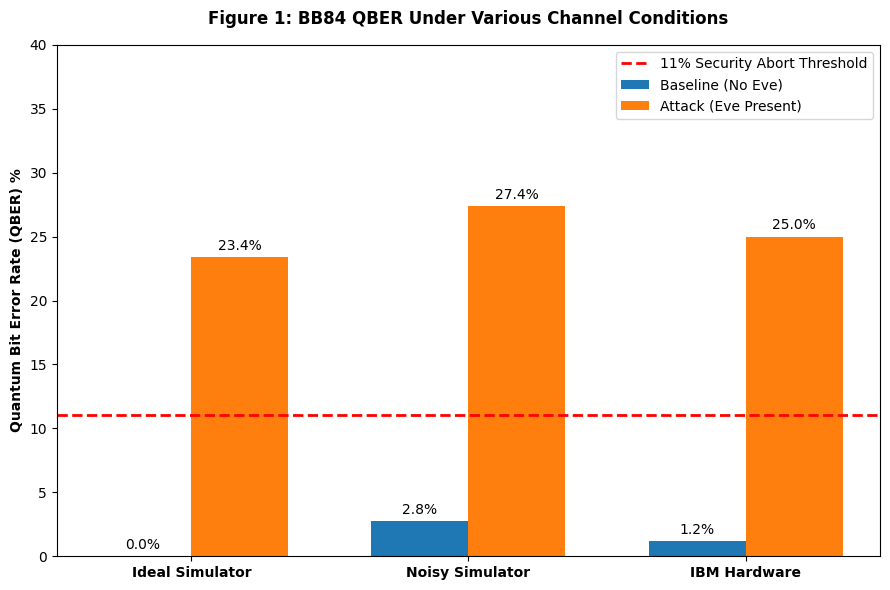

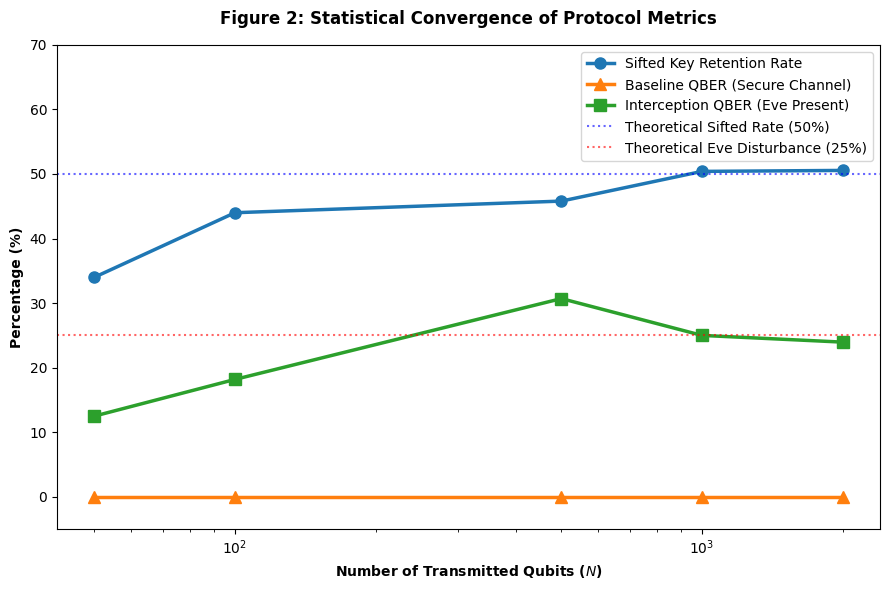

In [26]:
if __name__ == "__main__":    
    # local simulator tests
    tc1_qber = test_case_1_no_eavesdropper(n=1000)
    tc2_qber = test_case_2_eve_present(n=1000)
    tc3_no_eve, tc3_eve = test_case_3_noisy_backend(n=1000)
    
    # scaling test
    n_scaling_values = [50, 100, 500, 1000, 2000]
    scaling_data_no_eve = test_case_4_qber_scaling_no_eve(n_scaling_values)
    scaling_data_eve    = test_case_4_qber_scaling_eve(n_scaling_values)
    
    # Run hardware test
    tc5_no_eve, tc5_eve = test_case_5_ibm_cloud_execution(n_per_circuit=100, n_circuits=10)
    
    qber_baseline = [tc1_qber, tc3_no_eve, tc5_no_eve]
    qber_attack   = [tc2_qber, tc3_eve, tc5_eve]
    
    print("\nGENERATING REPORTS...")
    plot_qber_comparison(qber_baseline, qber_attack)
    plot_scalability_convergence(
        n_values=scaling_data_no_eve["n_values"], 
        sifted_rates=scaling_data_no_eve["sifted_rates"], 
        no_eve_qbers=scaling_data_no_eve["eve_qbers"], # This is actually the 0% baseline
        eve_qbers=scaling_data_eve["eve_qbers"]
    )